# Step 2 — Look at the houses with charts

Before teaching a computer to predict prices, we look at the houses ourselves. **EDA** simply means “explore the data.”

A chart helps us ask: **Which house details seem connected to price?** Run the cells in order. The short sentence after each chart says what we see.

## Load the data
Use the same 1,460 houses as Step 1. We set the later rows aside because their prices may not be real sales.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/raw/House_Prices.csv')
sales = df[df['Id'] <= 1460]
print('Houses:', len(sales))

Houses: 1460


## 1. How are prices spread out?
Each bar counts houses in a price range. A tall bar means many houses sold in that range.

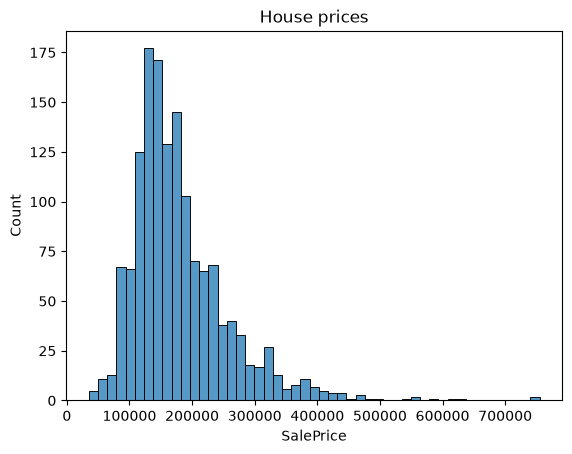

In [2]:
sns.histplot(data=sales, x='SalePrice')
plt.title('House prices')
plt.show()

**What we see:** Most houses cost much less than the most expensive houses. The middle price is **163,000**. Very high prices are uncommon, so we should check them when judging the model later.

## 2. Does a bigger house cost more?
Each dot is one house. Left/right shows its living area; up/down shows its price.

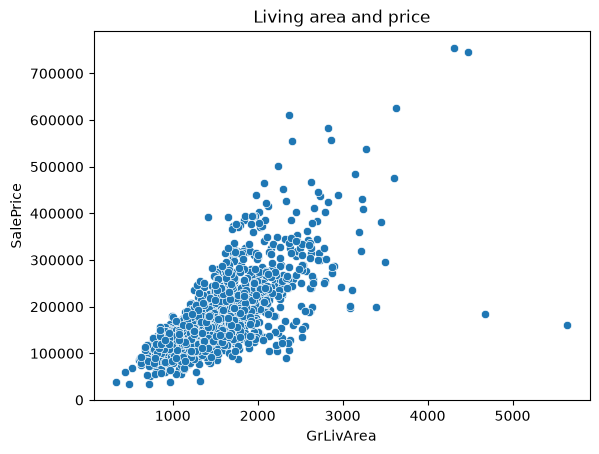

In [3]:
sns.scatterplot(data=sales, x='GrLivArea', y='SalePrice')
plt.title('Living area and price')
plt.show()

**What we see:** The dots generally go upward. Bigger houses usually cost more. **Living area** should help the model.

## 3. Does quality matter?
`OverallQual` is a quality score from 1 to 10. Each bar shows the **middle price** for houses with that score.

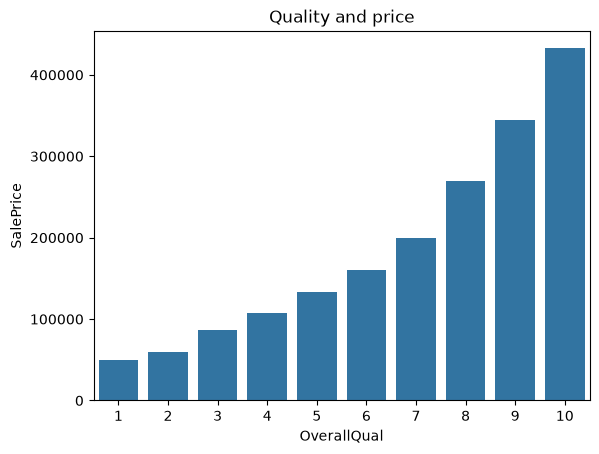

In [4]:
sns.barplot(data=sales, x='OverallQual', y='SalePrice',
            estimator='median', errorbar=None)
plt.title('Quality and price')
plt.show()

**What we see:** Higher quality scores have higher bars. **Overall quality** should help the model.

## 4. Does the neighborhood matter?
Each bar shows the middle price in one neighborhood. A longer bar means a higher typical price.

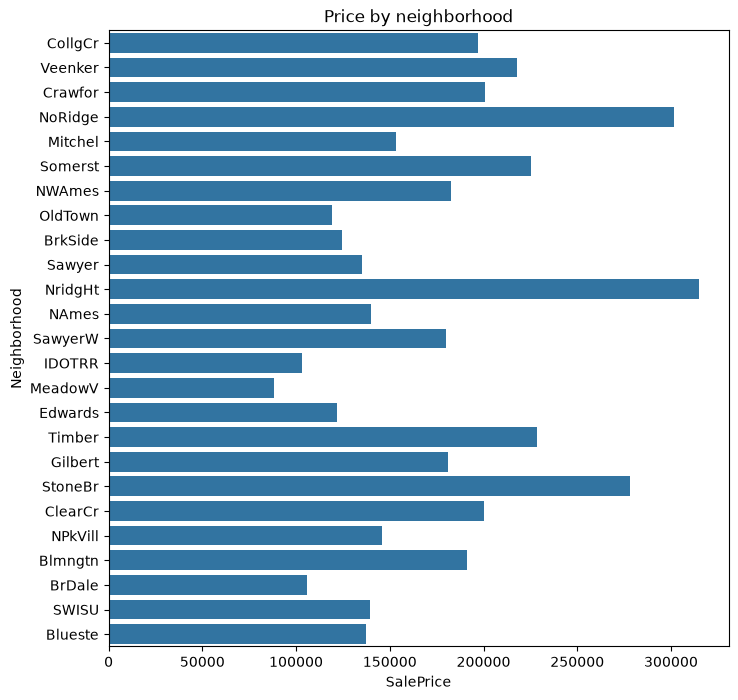

In [5]:
plt.figure(figsize=(8, 8))
sns.barplot(data=sales, x='SalePrice', y='Neighborhood',
            estimator='median', errorbar=None)
plt.title('Price by neighborhood')
plt.show()

**What we see:** Some neighborhoods have much longer bars than others. **Neighborhood** should help the model. Some areas have only a few houses, so their middle price is less certain.

## 5. Does the building year matter?
Each dot is one house. Left/right is its building year; up/down is its price.

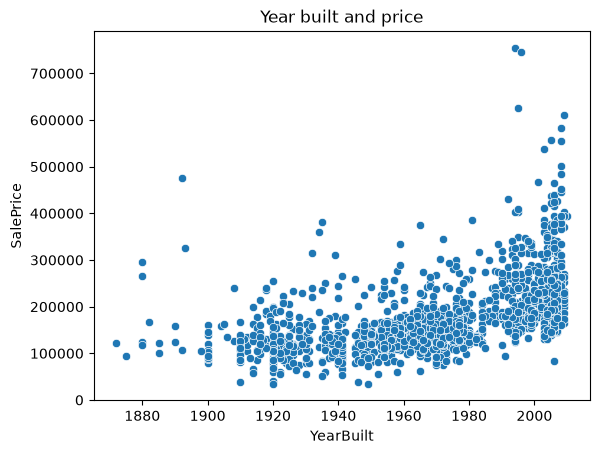

In [6]:
sns.scatterplot(data=sales, x='YearBuilt', y='SalePrice')
plt.title('Year built and price')
plt.show()

**What we see:** Newer houses often cost more, but not always. **Building year** may help the model, together with other details.

## 6. Which number columns move with price?
The table below uses numbers called **correlations**. A number near **1** means two things often rise together. A number near **0** means little straight-line pattern. This does not prove that one causes the other.

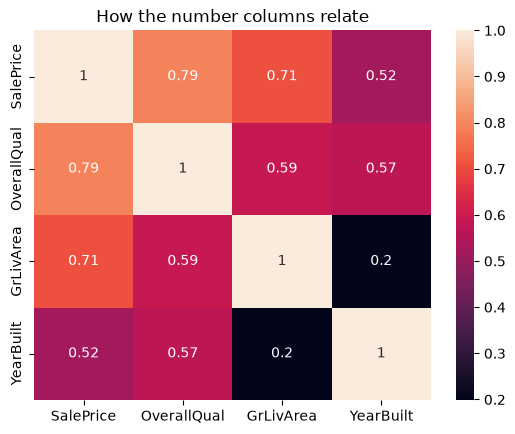

In [7]:
small = sales[['SalePrice', 'OverallQual', 'GrLivArea', 'YearBuilt']]
sns.heatmap(small.corr(), annot=True)
plt.title('How the number columns relate')
plt.show()

**What we see:** Price is most connected to **quality (0.79)** and **living area (0.71)** in this small table. Building year also has a positive number (**0.52**). These look like useful model inputs.

## Simple conclusion

- Bigger and higher-quality houses often sell for more.
- Prices change across neighborhoods.
- Newer houses often cost more, but the pattern is not perfect.

These are **clues**, not rules for every house. In the next step, we can try useful new house details before training a model.